In [1]:
checkpoint = "prajjwal1/bert-tiny"
tokenizer_checkpoint = "bert-base-uncased"
dataset_name = "imdb"

from transformers import AutoModel

model = AutoModel.from_pretrained(checkpoint)

from pathlib import Path
import dill

with open(f"{Path.home()}/tutorial_5_best_model.pkl", "rb") as f:
    base_model = dill.load(f)


    
from chop.tools import get_tokenized_dataset

dataset, tokenizer = get_tokenized_dataset(
    dataset=dataset_name,
    checkpoint=tokenizer_checkpoint,
    return_tokenizer=True,
)

/home/ism/ADL/mase/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/ism/ADL/mase/.venv/lib/python3.11/site-packages/torch/cuda/__init__.py:61: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]
INFO     Tokenizing dataset imdb with AutoTokenizer for bert-base-uncased.


# Lab 3: Mixed Precision Quantization Search

## Task 1 — Per-layer Integer Width Search

> *"In Tutorial 6, all layers allocated to IntegerLinear are allocated the same width and fractional width. This is suboptimal, as different layers may have different sensitivities to quantization. Modify the code to allow different layers to have widths in the range [8, 16, 32] and fractional widths in the range [2, 4, 8]. Expose this choice as an additional hyperparameter for the Optuna sampler. Run the search again, and plot a figure that has the number of trials on the x axis, and the maximum achieved accuracy up to that point on the y axis."*

In [9]:
# Task 1: Per-layer Integer width search
# Search space: each Linear layer independently chooses nn.Linear or LinearInteger
# with per-layer width ∈ {8, 16, 32} and frac_width ∈ {2, 4, 8}

import torch
from chop.nn.quantized.modules.linear import LinearInteger
from chop.tools.utils import deepsetattr
from copy import deepcopy

task1_search_space = {
    "int_width": [8, 16, 32],
    "frac_width": [2, 4, 8],
    "linear_layer_choices": [torch.nn.Linear, LinearInteger],
}


def construct_model_task1(trial):
    trial_model = deepcopy(base_model)

    for name, layer in trial_model.named_modules():
        if isinstance(layer, torch.nn.Linear):
            new_layer_cls = trial.suggest_categorical(
                f"{name}_type",
                task1_search_space["linear_layer_choices"],
            )

            if new_layer_cls == torch.nn.Linear:
                continue

            # Per-layer width and frac_width selection
            idx_w = trial.suggest_int(
                f"{name}_width_idx", 0, len(task1_search_space["int_width"]) - 1
            )
            idx_f = trial.suggest_int(
                f"{name}_frac_width_idx", 0, len(task1_search_space["frac_width"]) - 1
            )
            w = task1_search_space["int_width"][idx_w]
            f = task1_search_space["frac_width"][idx_f]

            kwargs = {
                "in_features": layer.in_features,
                "out_features": layer.out_features,
                "config": {
                    "data_in_width": w,
                    "data_in_frac_width": f,
                    "weight_width": w,
                    "weight_frac_width": f,
                    "bias_width": w,
                    "bias_frac_width": f,
                },
            }

            new_layer = LinearInteger(**kwargs)
            new_layer.weight.data = layer.weight.data.clone()
            if layer.bias is not None:
                new_layer.bias.data = layer.bias.data.clone()
            deepsetattr(trial_model, name, new_layer)

    return trial_model

In [ ]:
# Task 1: Run the search
from chop.tools import get_trainer
from optuna.samplers import RandomSampler
import optuna

def objective_task1(trial):
    model = construct_model_task1(trial)

    trainer = get_trainer(
        model=model,
        tokenized_dataset=dataset,
        tokenizer=tokenizer,
        evaluate_metric="accuracy",
        num_train_epochs=3,
    )

    trainer.train()
    eval_results = trainer.evaluate()
    trial.set_user_attr("model", model)
    return eval_results["eval_accuracy"]

study_task1 = optuna.create_study(
    direction="maximize",
    study_name="task1-per-layer-integer-search",
    sampler=RandomSampler(),
)

study_task1.optimize(
    objective_task1,
    n_trials=100,
    timeout=60 * 60 * 24,
)

[I 2026-02-07 23:34:33,712] A new study created in memory with name: task1-per-layer-integer-search
/home/ism/ADL/mase/.venv/lib/python3.11/site-packages/optuna/distributions.py:502: UserWarning: Choices for a categorical distribution should be a tuple of None, bool, int, float and str for persistent storage but contains <class 'torch.nn.modules.linear.Linear'> which is of type type.
  warnings.warn(message)
/home/ism/ADL/mase/.venv/lib/python3.11/site-packages/optuna/distributions.py:502: UserWarning: Choices for a categorical distribution should be a tuple of None, bool, int, float and str for persistent storage but contains <class 'chop.nn.quantized.modules.linear.LinearInteger'> which is of type type.
  warnings.warn(message)
/home/ism/ADL/mase/src/chop/tools/huggingface.py:157: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Step,Training Loss
500,0.376700
1000,0.332500
1500,0.332900
2000,0.365800
2500,0.343900
3000,0.377500
3500,0.314500
4000,0.280300
4500,0.290800
5000,0.306200


[I 2026-02-07 23:36:39,922] Trial 0 finished with value: 0.87704 and parameters: {'bert.encoder.layer.0.attention.self.query_type': <class 'torch.nn.modules.linear.Linear'>, 'bert.encoder.layer.0.attention.self.value_type': <class 'chop.nn.quantized.modules.linear.LinearInteger'>, 'bert.encoder.layer.0.attention.self.value_width_idx': 2, 'bert.encoder.layer.0.attention.self.value_frac_width_idx': 1, 'bert.encoder.layer.0.intermediate.dense_type': <class 'chop.nn.quantized.modules.linear.LinearInteger'>, 'bert.encoder.layer.0.intermediate.dense_width_idx': 0, 'bert.encoder.layer.0.intermediate.dense_frac_width_idx': 2, 'bert.encoder.layer.0.output.dense_type': <class 'torch.nn.modules.linear.Linear'>, 'bert.encoder.layer.1.attention.output.dense_type': <class 'torch.nn.modules.linear.Linear'>, 'bert.encoder.layer.1.intermediate.dense_type': <class 'chop.nn.quantized.modules.linear.LinearInteger'>, 'bert.encoder.layer.1.intermediate.dense_width_idx': 0, 'bert.encoder.layer.1.intermediate

Step,Training Loss
500,0.693100
1000,0.693100
1500,0.688300
2000,0.575300
2500,0.466900
3000,0.422600
3500,0.396800
4000,0.348700
4500,0.322400
5000,0.319300


[I 2026-02-07 23:38:30,820] Trial 1 finished with value: 0.86676 and parameters: {'bert.encoder.layer.0.attention.self.query_type': <class 'chop.nn.quantized.modules.linear.LinearInteger'>, 'bert.encoder.layer.0.attention.self.query_width_idx': 1, 'bert.encoder.layer.0.attention.self.query_frac_width_idx': 2, 'bert.encoder.layer.0.attention.self.value_type': <class 'torch.nn.modules.linear.Linear'>, 'bert.encoder.layer.0.intermediate.dense_type': <class 'torch.nn.modules.linear.Linear'>, 'bert.encoder.layer.0.output.dense_type': <class 'torch.nn.modules.linear.Linear'>, 'bert.encoder.layer.1.attention.output.dense_type': <class 'chop.nn.quantized.modules.linear.LinearInteger'>, 'bert.encoder.layer.1.attention.output.dense_width_idx': 1, 'bert.encoder.layer.1.attention.output.dense_frac_width_idx': 2, 'bert.encoder.layer.1.intermediate.dense_type': <class 'torch.nn.modules.linear.Linear'>, 'bert.encoder.layer.1.output.dense_type': <class 'chop.nn.quantized.modules.linear.LinearInteger'>

...

[I 2026-02-08 00:06:50,636] Trial 17 finished with value: 0.87336 and parameters: {'bert.encoder.layer.0.attention.self.query_type': <class 'chop.nn.quantized.modules.linear.LinearInteger'>, 'bert.encoder.layer.0.attention.self.query_width_idx': 2, 'bert.encoder.layer.0.attention.self.query_frac_width_idx': 1, 'bert.encoder.layer.0.attention.self.value_type': <class 'chop.nn.quantized.modules.linear.LinearInteger'>, 'bert.encoder.layer.0.attention.self.value_width_idx': 0, 'bert.encoder.layer.0.attention.self.value_frac_width_idx': 0, 'bert.encoder.layer.0.intermediate.dense_type': <class 'torch.nn.modules.linear.Linear'>, 'bert.encoder.layer.0.output.dense_type': <class 'torch.nn.modules.linear.Linear'>, 'bert.encoder.layer.1.attention.output.dense_type': <class 'chop.nn.quantized.modules.linear.LinearInteger'>, 'bert.encoder.layer.1.attention.output.dense_width_idx': 0, 'bert.encoder.layer.1.attention.output.dense_frac_width_idx': 1, 'bert.encoder.layer.1.intermediate.dense_type': <c

Step,Training Loss
500,0.394600
1000,0.319200
1500,0.313800
2000,0.332100
2500,0.317700
3000,0.339700
3500,0.279400
4000,0.246800
4500,0.238700
5000,0.266500


[I 2026-02-08 00:08:52,368] Trial 18 finished with value: 0.87864 and parameters: {'bert.encoder.layer.0.attention.self.query_type': <class 'chop.nn.quantized.modules.linear.LinearInteger'>, 'bert.encoder.layer.0.attention.self.query_width_idx': 2, 'bert.encoder.layer.0.attention.self.query_frac_width_idx': 1, 'bert.encoder.layer.0.attention.self.value_type': <class 'torch.nn.modules.linear.Linear'>, 'bert.encoder.layer.0.intermediate.dense_type': <class 'chop.nn.quantized.modules.linear.LinearInteger'>, 'bert.encoder.layer.0.intermediate.dense_width_idx': 2, 'bert.encoder.layer.0.intermediate.dense_frac_width_idx': 2, 'bert.encoder.layer.0.output.dense_type': <class 'chop.nn.quantized.modules.linear.LinearInteger'>, 'bert.encoder.layer.0.output.dense_width_idx': 1, 'bert.encoder.layer.0.output.dense_frac_width_idx': 0, 'bert.encoder.layer.1.attention.output.dense_type': <class 'chop.nn.quantized.modules.linear.LinearInteger'>, 'bert.encoder.layer.1.attention.output.dense_width_idx': 2

Step,Training Loss
500,0.368100
1000,0.327500
1500,0.322500
2000,0.351600
2500,0.331300
3000,0.364500
3500,0.298900
4000,0.263200
4500,0.266000
5000,0.286800


[I 2026-02-08 00:10:41,144] Trial 19 finished with value: 0.87832 and parameters: {'bert.encoder.layer.0.attention.self.query_type': <class 'torch.nn.modules.linear.Linear'>, 'bert.encoder.layer.0.attention.self.value_type': <class 'torch.nn.modules.linear.Linear'>, 'bert.encoder.layer.0.intermediate.dense_type': <class 'chop.nn.quantized.modules.linear.LinearInteger'>, 'bert.encoder.layer.0.intermediate.dense_width_idx': 2, 'bert.encoder.layer.0.intermediate.dense_frac_width_idx': 1, 'bert.encoder.layer.0.output.dense_type': <class 'torch.nn.modules.linear.Linear'>, 'bert.encoder.layer.1.attention.output.dense_type': <class 'chop.nn.quantized.modules.linear.LinearInteger'>, 'bert.encoder.layer.1.attention.output.dense_width_idx': 1, 'bert.encoder.layer.1.attention.output.dense_frac_width_idx': 2, 'bert.encoder.layer.1.intermediate.dense_type': <class 'chop.nn.quantized.modules.linear.LinearInteger'>, 'bert.encoder.layer.1.intermediate.dense_width_idx': 1, 'bert.encoder.layer.1.interme

In [ ]:
# Task 1: Plot cumulative maximum accuracy vs trial number
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Extract results
task1_results = []
for trial in study_task1.trials:
    # Determine per-layer config summary
    widths_used = set()
    fracs_used = set()
    is_quantized = False
    for key, val in trial.params.items():
        if key.endswith("_type") and val != torch.nn.Linear:
            is_quantized = True
        if key.endswith("_width_idx"):
            widths_used.add(task1_search_space["int_width"][val])
        if key.endswith("_frac_width_idx"):
            fracs_used.add(task1_search_space["frac_width"][val])

    task1_results.append({
        "trial_number": trial.number,
        "accuracy": trial.value if trial.value is not None else 0.0,
        "state": trial.state.name,
        "quantized": is_quantized,
        "widths": sorted(widths_used) if widths_used else [],
        "frac_widths": sorted(fracs_used) if fracs_used else [],
    })

df_task1 = pd.DataFrame(task1_results)

# Plot cumulative max accuracy
df_complete = df_task1[df_task1["state"] == "COMPLETE"].sort_values("trial_number")
cummax = df_complete["accuracy"].cummax()

plt.figure(figsize=(10, 5))
plt.plot(df_complete["trial_number"], cummax, marker='o', linewidth=2, color='tab:blue', label='Cumulative Max')
plt.scatter(df_complete["trial_number"], df_complete["accuracy"], alpha=0.4, color='tab:orange', s=40, label='Individual Trial')
plt.xlabel('Trial Number', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.title('Task 1: Per-Layer Integer Width Search — Cumulative Max Accuracy', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Print best trial details
best = study_task1.best_trial
print(f"\nBest Trial #{best.number}: accuracy = {best.value:.4f}")
print("Per-layer configurations:")
for key, val in sorted(best.params.items()):
    if key.endswith("_type"):
        layer_name = key.replace("_type", "")
        is_int = val != torch.nn.Linear
        if is_int:
            w_idx = best.params.get(f"{layer_name}_width_idx", "?")
            f_idx = best.params.get(f"{layer_name}_frac_width_idx", "?")
            w = task1_search_space["int_width"][w_idx] if isinstance(w_idx, int) else "?"
            f = task1_search_space["frac_width"][f_idx] if isinstance(f_idx, int) else "?"
            print(f"  {layer_name}: LinearInteger(width={w}, frac_width={f})")
        else:
            print(f"  {layer_name}: nn.Linear (full precision)")

print(f"\nTotal trials: {len(df_task1)}")
print(f"Successful: {len(df_complete)}")

## Task 2 — All Precision Types Search

> *"Extend the search to consider all supported precisions for the Linear layer in Mase, including Minifloat, BlockFP, BlockLog, Binary, etc. This may also require changing the model constructor so the required arguments are passed when instantiating each layer. Run the search again, and plot a figure that has the number of trials on the x axis, and the maximum achieved accuracy up to that point on the y axis. Plot one curve for each precision to compare their performance."*

All 10 quantized precision types are included after patching MASE library bugs:
- **LinearInteger**: Fixed-point quantization with configurable integer and fractional widths
- **LinearMinifloatDenorm/IEEE**: Low-precision floating-point with denormal or IEEE rounding
- **LinearLog**: Logarithmic quantization 
- **LinearBlockFP/BlockMinifloat/BlockLog**: Block-based quantization (required `block_size` as list and `backward()` signature fix)
- **LinearBinary/BinaryScaling**: Binary quantization (required dimension-agnostic fix in `BinaryBipolarScaled`/`BinaryZeroScaled`)
- **LinearBinaryResidualSign**: Binary with residual sign for multi-level quantization

In [ ]:
# Defining Search Space

import torch
from chop.nn.quantized.modules.linear import (
    LinearInteger,
    LinearMinifloatDenorm,
    LinearMinifloatIEEE,
    LinearLog,
    LinearBlockFP,
    LinearBlockMinifloat,
    LinearBlockLog,
    LinearBinary,
    LinearBinaryScaling,
    LinearBinaryResidualSign,
)

search_space = {
    "frac_width": [2, 4, 8],
    "int_width": [8, 16, 32],
    "exponent_width": [2, 3, 4, 5],
    "block_size": [16, 32, 64],
    "linear_layer_choices": [
        torch.nn.Linear,
        LinearInteger,
        LinearMinifloatDenorm,
        LinearMinifloatIEEE,
        LinearLog,
        LinearBlockFP,
        LinearBlockMinifloat,
        LinearBlockLog,
        LinearBinary,
        LinearBinaryScaling,
        LinearBinaryResidualSign,
    ],
}


from chop.tools.utils import deepsetattr
from copy import deepcopy


def construct_model(trial):
    # Fetch the model
    trial_model = deepcopy(base_model)

    # Quantize layers according to optuna suggestions
    for name, layer in trial_model.named_modules():
        if isinstance(layer, torch.nn.Linear):
            new_layer_cls = trial.suggest_categorical(
                f"{name}_type",
                search_space["linear_layer_choices"],
            )

            if new_layer_cls == torch.nn.Linear:
                continue

            kwargs = {
                "in_features": layer.in_features,
                "out_features": layer.out_features,
            }

            # --- Integer ---
            if new_layer_cls == LinearInteger:
                idx_w = trial.suggest_int(f"{name}_int_width_idx", 0, len(search_space["int_width"]) - 1)
                idx_f = trial.suggest_int(f"{name}_frac_width_idx", 0, len(search_space["frac_width"]) - 1)
                
                kwargs["config"] = {
                    "data_in_width": search_space["int_width"][idx_w],
                    "data_in_frac_width": search_space["frac_width"][idx_f],
                    "weight_width": search_space["int_width"][idx_w],
                    "weight_frac_width": search_space["frac_width"][idx_f],
                    "bias_width": search_space["int_width"][idx_w],
                    "bias_frac_width": search_space["frac_width"][idx_f],
                }

            # --- Minifloat Denorm ---
            elif new_layer_cls == LinearMinifloatDenorm:
                idx_w = trial.suggest_int(f"{name}_mf_width_idx", 0, len(search_space["int_width"]) - 1)
                idx_e = trial.suggest_int(f"{name}_mf_exp_idx", 0, len(search_space["exponent_width"]) - 1)
                ew = search_space["exponent_width"][idx_e]
                
                kwargs["config"] = {
                    "weight_width": search_space["int_width"][idx_w],
                    "weight_exponent_width": ew,
                    "weight_exponent_bias": (2**(ew-1))-1,
                    "data_in_width": search_space["int_width"][idx_w],
                    "data_in_exponent_width": ew,
                    "data_in_exponent_bias": (2**(ew-1))-1,
                    "bias_width": search_space["int_width"][idx_w],
                    "bias_exponent_width": ew,
                    "bias_exponent_bias": (2**(ew-1))-1,
                }

            # --- Minifloat IEEE ---
            elif new_layer_cls == LinearMinifloatIEEE:
                idx_w = trial.suggest_int(f"{name}_ieee_width_idx", 0, len(search_space["int_width"]) - 1)
                idx_e = trial.suggest_int(f"{name}_ieee_exp_idx", 0, len(search_space["exponent_width"]) - 1)
                ew = search_space["exponent_width"][idx_e]

                kwargs["config"] = {
                    "weight_width": search_space["int_width"][idx_w],
                    "weight_exponent_width": ew,
                    "weight_exponent_bias": (2**(ew-1))-1,
                    "data_in_width": search_space["int_width"][idx_w],
                    "data_in_exponent_width": ew,
                    "data_in_exponent_bias": (2**(ew-1))-1,
                    "bias_width": search_space["int_width"][idx_w],
                    "bias_exponent_width": ew,
                    "bias_exponent_bias": (2**(ew-1))-1,
                }

            # --- Log ---
            elif new_layer_cls == LinearLog:
                idx_w = trial.suggest_int(f"{name}_log_width_idx", 0, len(search_space["int_width"]) - 1)
                kwargs["config"] = {
                    "weight_width": search_space["int_width"][idx_w],
                    "weight_exponent_bias": 127,
                    "data_in_width": search_space["int_width"][idx_w],
                    "data_in_exponent_bias": 127,
                    "bias_width": search_space["int_width"][idx_w],
                    "bias_exponent_bias": 127,
                }

            # --- Block FP ---
            elif new_layer_cls == LinearBlockFP:
                idx_w = trial.suggest_int(f"{name}_bfp_width_idx", 0, len(search_space["int_width"]) - 1)
                idx_b = trial.suggest_int(f"{name}_bfp_block_idx", 0, len(search_space["block_size"]) - 1)
                bs = [search_space["block_size"][idx_b]]

                kwargs["config"] = {
                    "weight_width": search_space["int_width"][idx_w],
                    "weight_exponent_width": 8,
                    "weight_exponent_bias": 127,
                    "weight_block_size": bs,
                    "data_in_width": search_space["int_width"][idx_w],
                    "data_in_exponent_width": 8,
                    "data_in_exponent_bias": 127,
                    "data_in_block_size": bs,
                    "bias_width": search_space["int_width"][idx_w],
                    "bias_exponent_width": 8,
                    "bias_exponent_bias": 127,
                    "bias_block_size": bs,
                }

            # --- Block Minifloat ---
            elif new_layer_cls == LinearBlockMinifloat:
                idx_w = trial.suggest_int(f"{name}_bmf_width_idx", 0, len(search_space["int_width"]) - 1)
                idx_e = trial.suggest_int(f"{name}_bmf_exp_idx", 0, len(search_space["exponent_width"]) - 1)
                idx_b = trial.suggest_int(f"{name}_bmf_block_idx", 0, len(search_space["block_size"]) - 1)
                bs = [search_space["block_size"][idx_b]]

                kwargs["config"] = {
                    "weight_width": search_space["int_width"][idx_w],
                    "weight_exponent_width": search_space["exponent_width"][idx_e],
                    "weight_exponent_bias_width": search_space["exponent_width"][idx_e],
                    "weight_block_size": bs,
                    "data_in_width": search_space["int_width"][idx_w],
                    "data_in_exponent_width": search_space["exponent_width"][idx_e],
                    "data_in_exponent_bias_width": search_space["exponent_width"][idx_e],
                    "data_in_block_size": bs,
                    "bias_width": search_space["int_width"][idx_w],
                    "bias_exponent_width": search_space["exponent_width"][idx_e],
                    "bias_exponent_bias_width": search_space["exponent_width"][idx_e],
                    "bias_block_size": bs,
                }

            # --- Block Log ---
            elif new_layer_cls == LinearBlockLog:
                idx_w = trial.suggest_int(f"{name}_blog_width_idx", 0, len(search_space["int_width"]) - 1)
                idx_b = trial.suggest_int(f"{name}_blog_block_idx", 0, len(search_space["block_size"]) - 1)
                bs = [search_space["block_size"][idx_b]]

                kwargs["config"] = {
                    "weight_width": search_space["int_width"][idx_w],
                    "weight_exponent_bias_width": 3,
                    "weight_block_size": bs,
                    "data_in_width": search_space["int_width"][idx_w],
                    "data_in_exponent_bias_width": 3,
                    "data_in_block_size": bs,
                    "bias_width": search_space["int_width"][idx_w],
                    "bias_exponent_bias_width": 3,
                    "bias_block_size": bs,
                }

            # --- Binary ---
            elif new_layer_cls == LinearBinary:
                kwargs["config"] = {
                    "weight_stochastic": trial.suggest_categorical(f"{name}_bin_stoch", [True, False]),
                    "weight_bipolar": trial.suggest_categorical(f"{name}_bin_bipol", [True, False]),
                }

            # --- Binary Scaling ---
            elif new_layer_cls == LinearBinaryScaling:
                kwargs["config"] = {
                    "data_in_stochastic": trial.suggest_categorical(f"{name}_bins_in_stoch", [True, False]),
                    "bias_stochastic": False,
                    "weight_stochastic": trial.suggest_categorical(f"{name}_bins_w_stoch", [True, False]),
                    "data_in_bipolar": True,
                    "bias_bipolar": True,
                    "weight_bipolar": True,
                    "binary_training": True,
                }

            # --- Binary Residual Sign ---
            elif new_layer_cls == LinearBinaryResidualSign:
                kwargs["config"] = {
                    "data_in_stochastic": trial.suggest_categorical(f"{name}_brs_in_stoch", [True, False]),
                    "weight_stochastic": trial.suggest_categorical(f"{name}_brs_w_stoch", [True, False]),
                    "data_in_bipolar": True,
                    "weight_bipolar": True,
                    "binary_training": True,
                    "data_in_levels": 2,
                    "data_in_residual_sign": True,
                }

            # Create the new layer (copy the weights)
            new_layer = new_layer_cls(**kwargs)
            new_layer.weight.data = layer.weight.data.clone()
            if layer.bias is not None and hasattr(new_layer, 'bias') and new_layer.bias is not None:
                new_layer.bias.data = layer.bias.data.clone()

            # Replace the layer in the model
            deepsetattr(trial_model, name, new_layer)

    return trial_model


### Task 2: Smoke Test & Study Execution

In [4]:
# Quick smoke test: forward + backward pass for every layer type with 2D Linear weights
import torch
from chop.nn.quantized.modules.linear import (
    LinearInteger,
    LinearMinifloatDenorm,
    LinearMinifloatIEEE,
    LinearLog,
    LinearBlockFP,
    LinearBlockMinifloat,
    LinearBlockLog,
    LinearBinary,
    LinearBinaryScaling,
    LinearBinaryResidualSign,
)

test_configs = {
    "LinearInteger": (LinearInteger, {
        "data_in_width": 8, "data_in_frac_width": 4,
        "weight_width": 8, "weight_frac_width": 4,
        "bias_width": 8, "bias_frac_width": 4,
    }),
    "LinearMinifloatDenorm": (LinearMinifloatDenorm, {
        "weight_width": 8, "weight_exponent_width": 3, "weight_exponent_bias": 3,
        "data_in_width": 8, "data_in_exponent_width": 3, "data_in_exponent_bias": 3,
        "bias_width": 8, "bias_exponent_width": 3, "bias_exponent_bias": 3,
    }),
    "LinearMinifloatIEEE": (LinearMinifloatIEEE, {
        "weight_width": 8, "weight_exponent_width": 3, "weight_exponent_bias": 3,
        "data_in_width": 8, "data_in_exponent_width": 3, "data_in_exponent_bias": 3,
        "bias_width": 8, "bias_exponent_width": 3, "bias_exponent_bias": 3,
    }),
    "LinearLog": (LinearLog, {
        "weight_width": 8, "weight_exponent_bias": 127,
        "data_in_width": 8, "data_in_exponent_bias": 127,
        "bias_width": 8, "bias_exponent_bias": 127,
    }),
    "LinearBlockFP": (LinearBlockFP, {
        "weight_width": 8, "weight_exponent_width": 8, "weight_exponent_bias": 127, "weight_block_size": [32],
        "data_in_width": 8, "data_in_exponent_width": 8, "data_in_exponent_bias": 127, "data_in_block_size": [32],
        "bias_width": 8, "bias_exponent_width": 8, "bias_exponent_bias": 127, "bias_block_size": [32],
    }),
    "LinearBlockMinifloat": (LinearBlockMinifloat, {
        "weight_width": 8, "weight_exponent_width": 3, "weight_exponent_bias_width": 3, "weight_block_size": [32],
        "data_in_width": 8, "data_in_exponent_width": 3, "data_in_exponent_bias_width": 3, "data_in_block_size": [32],
        "bias_width": 8, "bias_exponent_width": 3, "bias_exponent_bias_width": 3, "bias_block_size": [32],
    }),
    "LinearBlockLog": (LinearBlockLog, {
        "weight_width": 8, "weight_exponent_bias_width": 3, "weight_block_size": [32],
        "data_in_width": 8, "data_in_exponent_bias_width": 3, "data_in_block_size": [32],
        "bias_width": 8, "bias_exponent_bias_width": 3, "bias_block_size": [32],
    }),
    "LinearBinary": (LinearBinary, {
        "weight_stochastic": False, "weight_bipolar": True,
    }),
    "LinearBinaryScaling": (LinearBinaryScaling, {
        "data_in_stochastic": False, "bias_stochastic": False, "weight_stochastic": False,
        "data_in_bipolar": True, "bias_bipolar": True, "weight_bipolar": True,
        "binary_training": True,
    }),
    "LinearBinaryResidualSign": (LinearBinaryResidualSign, {
        "data_in_stochastic": False, "weight_stochastic": False,
        "data_in_bipolar": True, "weight_bipolar": True,
        "binary_training": True,
        "data_in_levels": 2, "data_in_residual_sign": True,
    }),
}

x = torch.randn(4, 64, requires_grad=True)  # batch=4, features=64

results = {}
for name, (cls, config) in test_configs.items():
    try:
        layer = cls(in_features=64, out_features=32, config=config)
        out = layer(x)
        loss = out.sum()
        loss.backward()
        results[name] = "✅ PASS"
    except Exception as e:
        results[name] = f"❌ FAIL: {type(e).__name__}: {e}"

print("=" * 60)
print("Layer Smoke Test Results (forward + backward)")
print("=" * 60)
for name, result in results.items():
    print(f"  {name:30s} {result}")
print("=" * 60)
working = sum(1 for r in results.values() if r.startswith("✅"))
print(f"\n{working}/{len(results)} layers working")

Layer Smoke Test Results (forward + backward)
  LinearInteger                  ✅ PASS
  LinearMinifloatDenorm          ✅ PASS
  LinearMinifloatIEEE            ✅ PASS
  LinearLog                      ✅ PASS
  LinearBlockFP                  ✅ PASS
  LinearBlockMinifloat           ✅ PASS
  LinearBlockLog                 ✅ PASS
  LinearBinary                   ✅ PASS
  LinearBinaryScaling            ✅ PASS
  LinearBinaryResidualSign       ✅ PASS

10/10 layers working


In [ ]:
from chop.tools import get_trainer
from collections import Counter


def objective(trial):

    # Define the model
    model = construct_model(trial)

    trainer = get_trainer(
        model=model,
        tokenized_dataset=dataset,
        tokenizer=tokenizer,
        evaluate_metric="accuracy",
        num_train_epochs=3,
    )

    trainer.train()
    eval_results = trainer.evaluate()

    trial.set_user_attr("model", model)

    return eval_results["eval_accuracy"]


from optuna.samplers import RandomSampler

sampler = RandomSampler()

import optuna

study = optuna.create_study(
    direction="maximize",
    study_name="bert-tiny-nas-study",
    sampler=sampler,
)

# --- Seed one trial per precision type to guarantee full coverage ---
import torch
linear_layer_names = [
    name for name, layer in base_model.named_modules()
    if isinstance(layer, torch.nn.Linear)
]

n_choices = len(search_space["linear_layer_choices"])
for layer_cls in search_space["linear_layer_choices"]:
    seed_params = {}
    for name in linear_layer_names:
        seed_params[f"{name}_type"] = layer_cls
        # Set default hyperparameters for each type
        if layer_cls == LinearInteger:
            seed_params[f"{name}_int_width_idx"] = 0
            seed_params[f"{name}_frac_width_idx"] = 1
        elif layer_cls == LinearMinifloatDenorm:
            seed_params[f"{name}_mf_width_idx"] = 0
            seed_params[f"{name}_mf_exp_idx"] = 1
        elif layer_cls == LinearMinifloatIEEE:
            seed_params[f"{name}_ieee_width_idx"] = 0
            seed_params[f"{name}_ieee_exp_idx"] = 1
        elif layer_cls == LinearLog:
            seed_params[f"{name}_log_width_idx"] = 0
        elif layer_cls == LinearBlockFP:
            seed_params[f"{name}_bfp_width_idx"] = 0
            seed_params[f"{name}_bfp_block_idx"] = 1
        elif layer_cls == LinearBlockMinifloat:
            seed_params[f"{name}_bmf_width_idx"] = 0
            seed_params[f"{name}_bmf_exp_idx"] = 1
            seed_params[f"{name}_bmf_block_idx"] = 1
        elif layer_cls == LinearBlockLog:
            seed_params[f"{name}_blog_width_idx"] = 0
            seed_params[f"{name}_blog_block_idx"] = 1
        elif layer_cls == LinearBinary:
            seed_params[f"{name}_bin_stoch"] = False
            seed_params[f"{name}_bin_bipol"] = True
        elif layer_cls == LinearBinaryScaling:
            seed_params[f"{name}_bins_in_stoch"] = False
            seed_params[f"{name}_bins_w_stoch"] = False
        elif layer_cls == LinearBinaryResidualSign:
            seed_params[f"{name}_brs_in_stoch"] = False
            seed_params[f"{name}_brs_w_stoch"] = False
    study.enqueue_trial(seed_params)

n_random = 20
n_total = n_choices + n_random
print(f"Seeded {n_choices} trials (one per precision type)")
print(f"Starting study with {n_choices} seeded + {n_random} random = {n_total} total trials...")

study.optimize(
    objective,
    n_trials=n_total,
    timeout=60 * 60 * 24,
)

[I 2026-02-07 20:18:29,194] A new study created in memory with name: bert-tiny-nas-study


Seeded 7 trials (one per precision type)
Starting study with 7 seeded + 13 random = 20 total trials...


/home/ism/ADL/mase/.venv/lib/python3.11/site-packages/optuna/distributions.py:502: UserWarning: Choices for a categorical distribution should be a tuple of None, bool, int, float and str for persistent storage but contains <class 'torch.nn.modules.linear.Linear'> which is of type type.
  warnings.warn(message)
/home/ism/ADL/mase/.venv/lib/python3.11/site-packages/optuna/distributions.py:502: UserWarning: Choices for a categorical distribution should be a tuple of None, bool, int, float and str for persistent storage but contains <class 'chop.nn.quantized.modules.linear.LinearInteger'> which is of type type.
  warnings.warn(message)
/home/ism/ADL/mase/.venv/lib/python3.11/site-packages/optuna/distributions.py:502: UserWarning: Choices for a categorical distribution should be a tuple of None, bool, int, float and str for persistent storage but contains <class 'chop.nn.quantized.modules.linear.LinearMinifloatDenorm'> which is of type type.
  warnings.warn(message)
/home/ism/ADL/mase/.venv

Step,Training Loss
500,0.368600
1000,0.327100
1500,0.323100
2000,0.351200
2500,0.335400
3000,0.366000
3500,0.302900
4000,0.264000
4500,0.271700
5000,0.291200


[I 2026-02-07 20:20:04,215] Trial 0 finished with value: 0.87792 and parameters: {'bert.encoder.layer.0.attention.self.query_type': <class 'torch.nn.modules.linear.Linear'>, 'bert.encoder.layer.0.attention.self.value_type': <class 'torch.nn.modules.linear.Linear'>, 'bert.encoder.layer.0.intermediate.dense_type': <class 'torch.nn.modules.linear.Linear'>, 'bert.encoder.layer.0.output.dense_type': <class 'torch.nn.modules.linear.Linear'>, 'bert.encoder.layer.1.attention.output.dense_type': <class 'torch.nn.modules.linear.Linear'>, 'bert.encoder.layer.1.intermediate.dense_type': <class 'torch.nn.modules.linear.Linear'>, 'bert.encoder.layer.1.output.dense_type': <class 'torch.nn.modules.linear.Linear'>, 'classifier_type': <class 'torch.nn.modules.linear.Linear'>}. Best is trial 0 with value: 0.87792.
/home/ism/ADL/mase/.venv/lib/python3.11/site-packages/optuna/distributions.py:502: UserWarning: Choices for a categorical distribution should be a tuple of None, bool, int, float and str for pe

...

[I 2026-02-07 21:20:03,575] Trial 17 finished with value: 0.86912 and parameters: {'bert.encoder.layer.0.attention.self.query_type': <class 'chop.nn.quantized.modules.linear.LinearMinifloatDenorm'>, 'bert.encoder.layer.0.attention.self.query_mf_width_idx': 1, 'bert.encoder.layer.0.attention.self.query_mf_exp_idx': 1, 'bert.encoder.layer.0.attention.self.value_type': <class 'chop.nn.quantized.modules.linear.LinearBinaryScaling'>, 'bert.encoder.layer.0.attention.self.value_bins_in_stoch': True, 'bert.encoder.layer.0.attention.self.value_bins_w_stoch': False, 'bert.encoder.layer.0.intermediate.dense_type': <class 'chop.nn.quantized.modules.linear.LinearLog'>, 'bert.encoder.layer.0.intermediate.dense_log_width_idx': 0, 'bert.encoder.layer.0.output.dense_type': <class 'chop.nn.quantized.modules.linear.LinearLog'>, 'bert.encoder.layer.0.output.dense_log_width_idx': 2, 'bert.encoder.layer.1.attention.output.dense_type': <class 'chop.nn.quantized.modules.linear.LinearInteger'>, 'bert.encoder.l

Step,Training Loss
500,0.687800
1000,0.654700
1500,0.611300
2000,0.565800
2500,0.518400
3000,0.486700
3500,0.437400
4000,0.405800
4500,0.376800
5000,0.371200


[I 2026-02-07 21:22:59,539] Trial 18 finished with value: 0.85924 and parameters: {'bert.encoder.layer.0.attention.self.query_type': <class 'chop.nn.quantized.modules.linear.LinearInteger'>, 'bert.encoder.layer.0.attention.self.query_int_width_idx': 1, 'bert.encoder.layer.0.attention.self.query_frac_width_idx': 0, 'bert.encoder.layer.0.attention.self.value_type': <class 'chop.nn.quantized.modules.linear.LinearLog'>, 'bert.encoder.layer.0.attention.self.value_log_width_idx': 1, 'bert.encoder.layer.0.intermediate.dense_type': <class 'chop.nn.quantized.modules.linear.LinearMinifloatIEEE'>, 'bert.encoder.layer.0.intermediate.dense_ieee_width_idx': 0, 'bert.encoder.layer.0.intermediate.dense_ieee_exp_idx': 3, 'bert.encoder.layer.0.output.dense_type': <class 'chop.nn.quantized.modules.linear.LinearBinaryScaling'>, 'bert.encoder.layer.0.output.dense_bins_in_stoch': False, 'bert.encoder.layer.0.output.dense_bins_w_stoch': False, 'bert.encoder.layer.1.attention.output.dense_type': <class 'chop.

Step,Training Loss
500,0.693100
1000,0.693100
1500,0.693100
2000,0.693100
2500,0.693100
3000,0.693100
3500,0.693100
4000,0.693100
4500,0.693100
5000,0.693100


[I 2026-02-07 21:25:06,752] Trial 19 finished with value: 0.5 and parameters: {'bert.encoder.layer.0.attention.self.query_type': <class 'chop.nn.quantized.modules.linear.LinearBinary'>, 'bert.encoder.layer.0.attention.self.query_bin_stoch': True, 'bert.encoder.layer.0.attention.self.query_bin_bipol': False, 'bert.encoder.layer.0.attention.self.value_type': <class 'chop.nn.quantized.modules.linear.LinearBinary'>, 'bert.encoder.layer.0.attention.self.value_bin_stoch': False, 'bert.encoder.layer.0.attention.self.value_bin_bipol': False, 'bert.encoder.layer.0.intermediate.dense_type': <class 'torch.nn.modules.linear.Linear'>, 'bert.encoder.layer.0.output.dense_type': <class 'chop.nn.quantized.modules.linear.LinearBinaryScaling'>, 'bert.encoder.layer.0.output.dense_bins_in_stoch': True, 'bert.encoder.layer.0.output.dense_bins_w_stoch': False, 'bert.encoder.layer.1.attention.output.dense_type': <class 'chop.nn.quantized.modules.linear.LinearInteger'>, 'bert.encoder.layer.1.attention.output.d

In [6]:
# Extract results from study — track dominant (most frequent) precision type per trial
import pandas as pd
from collections import Counter

results = []
for trial in study.trials:
    # Collect ALL layer type assignments for this trial
    type_counts = Counter()
    for key, val in trial.params.items():
        if key.endswith("_type"):
            type_counts[val.__name__] += 1
    
    # Use the most common type as the "dominant" precision
    dominant_type = type_counts.most_common(1)[0][0] if type_counts else "Unknown"
    
    results.append({
        "trial_number": trial.number,
        "accuracy": trial.value if trial.value is not None else 0.0,
        "precision_type": dominant_type,
        "state": trial.state.name,
        "all_types": dict(type_counts),
    })

df = pd.DataFrame(results)
print(df[["trial_number", "accuracy", "precision_type", "state"]].to_string(index=False))
print(f"\nTotal trials: {len(df)}")
print(f"Successful trials: {len(df[df['state'] == 'COMPLETE'])}")
print(f"\nPrecision types seen: {sorted(df['precision_type'].unique())}")

 trial_number  accuracy        precision_type    state
            0   0.87792                Linear COMPLETE
            1   0.87804         LinearInteger COMPLETE
            2   0.87756 LinearMinifloatDenorm COMPLETE
            3   0.87856   LinearMinifloatIEEE COMPLETE
            4   0.87556             LinearLog COMPLETE
            5   0.82708          LinearBinary COMPLETE
            6   0.68380   LinearBinaryScaling COMPLETE
            7   0.64484 LinearMinifloatDenorm COMPLETE
            8   0.49088   LinearBinaryScaling COMPLETE
            9   0.87660         LinearInteger COMPLETE
           10   0.50000   LinearBinaryScaling COMPLETE
           11   0.86460   LinearMinifloatIEEE COMPLETE
           12   0.87272   LinearMinifloatIEEE COMPLETE
           13   0.86672             LinearLog COMPLETE
           14   0.86392   LinearMinifloatIEEE COMPLETE
           15   0.82100   LinearMinifloatIEEE COMPLETE
           16   0.85692          LinearBinary COMPLETE
          

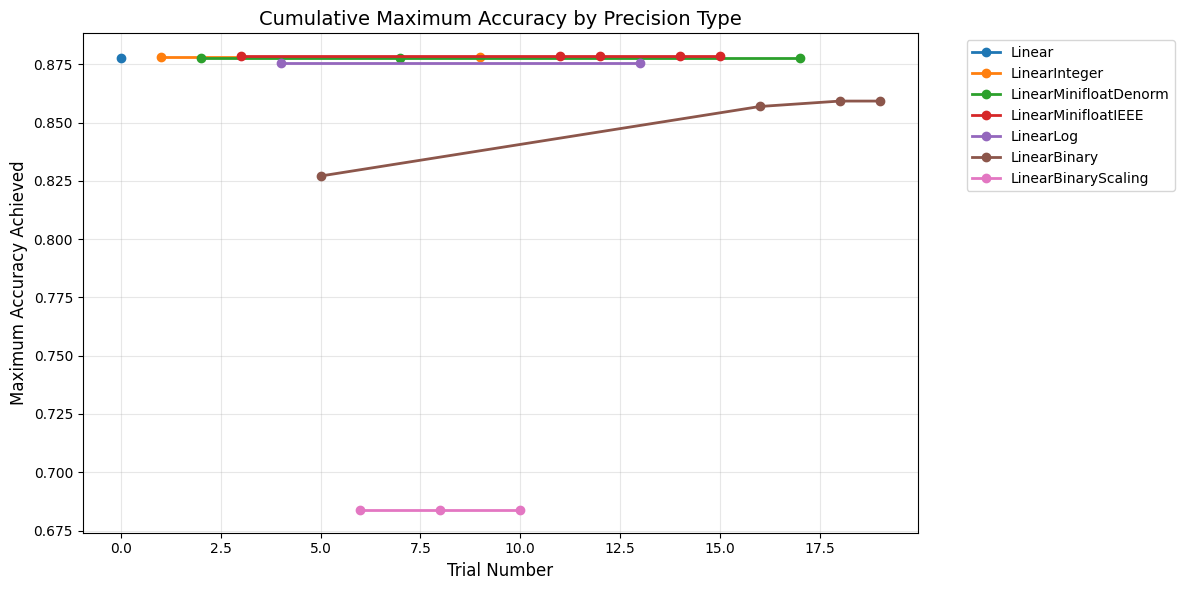


Summary by Precision Type:
                       count    mean     max     std
precision_type                                      
LinearMinifloatIEEE        5  0.8602  0.8786  0.0227
LinearInteger              2  0.8773  0.8780  0.0010
Linear                     1  0.8779  0.8779     NaN
LinearMinifloatDenorm      3  0.7972  0.8776  0.1320
LinearLog                  2  0.8711  0.8756  0.0063
LinearBinary               4  0.7608  0.8592  0.1745
LinearBinaryScaling        3  0.5582  0.6838  0.1088


In [ ]:
# Task 2: Cumulative max accuracy per precision type
import matplotlib.pyplot as plt
import numpy as np

# Only use completed trials
df_t2 = df[df['state'] == 'COMPLETE'].copy()
precision_types = df_t2['precision_type'].unique()

plt.figure(figsize=(12, 6))

for ptype in sorted(precision_types):
    if ptype is None:
        continue
    type_df = df_t2[df_t2['precision_type'] == ptype].sort_values('trial_number')
    cumulative_max = type_df['accuracy'].cummax()
    plt.plot(type_df['trial_number'], cumulative_max, marker='o', label=ptype, linewidth=2)

plt.xlabel('Trial Number', fontsize=12)
plt.ylabel('Maximum Accuracy Achieved', fontsize=12)
plt.title('Task 2: Cumulative Maximum Accuracy by Precision Type', fontsize=14)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Summary statistics
print("\nTask 2 — Summary by Precision Type:")
summary = df_t2.groupby('precision_type')['accuracy'].agg(['count', 'mean', 'max', 'std']).round(4)
print(summary.sort_values('max', ascending=False))

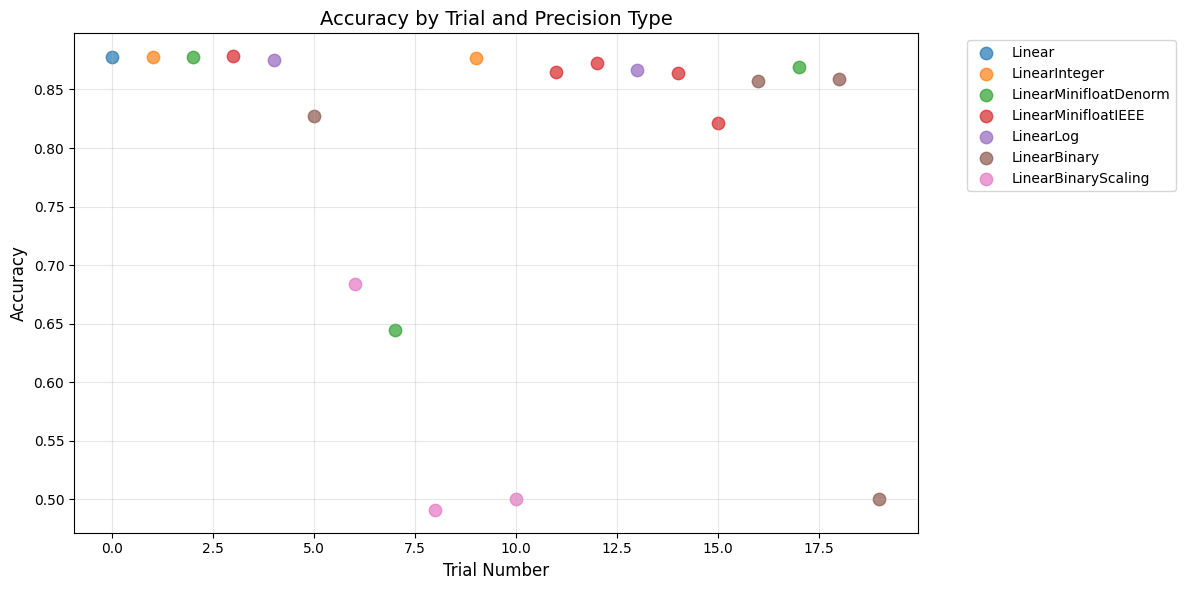

In [ ]:
# Task 2: Scatter plot of all trials by precision type
plt.figure(figsize=(12, 6))

for ptype in sorted(precision_types):
    if ptype is None:
        continue
    type_df = df_t2[df_t2['precision_type'] == ptype]
    plt.scatter(type_df['trial_number'], type_df['accuracy'], label=ptype, s=80, alpha=0.7)

plt.xlabel('Trial Number', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.title('Task 2: Accuracy by Trial and Precision Type', fontsize=14)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Print best trial
best_t2 = study.best_trial
print(f"\nTask 2 Best Trial #{best_t2.number}: accuracy = {best_t2.value:.4f}")
type_counts_best = Counter()
for key, val in best_t2.params.items():
    if key.endswith("_type"):
        type_counts_best[val.__name__] += 1
print(f"Layer types used: {dict(type_counts_best)}")